In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
folder_path = "rezKlasifikacije/"

svi_podaci = []

# Prođi kroz sve fajlove u folderu
for file in os.listdir(folder_path):
    if file.endswith(".xlsx"):
        file_path = os.path.join(folder_path, file)
        
        df = pd.read_excel(file_path)
        df["dataset"] = file   # naziv fajla kao ime skupa
        
        svi_podaci.append(df)

# Spoji sve u jedan DataFrame
df_all = pd.concat(svi_podaci, ignore_index=True)

# Ako su brojevi sa zarezom umjesto tačke
df_all["recall"] = df_all["recall"].astype(str).str.replace(",", ".").astype(float)
df_all["precision"] = df_all["precision"].astype(str).str.replace(",", ".").astype(float)
df_all["f1_score_true"] = df_all["f1_score_true"].astype(str).str.replace(",", ".").astype(float)
df_all["accuracy"] = df_all["accuracy"].astype(str).str.replace(",", ".").astype(float)

modeli = df_all["model"].unique()

rezultati = []

for model in modeli:
    df_model = df_all[df_all["model"] == model]
    
    max_recall = df_model.loc[df_model["recall"].idxmax()]
    max_precision = df_model.loc[df_model["precision"].idxmax()]
    max_f1 = df_model.loc[df_model["f1_score_true"].idxmax()]
    ac = df_model.loc[df_model["accuracy"].idxmax()]

    rezultati.append({
        "Model": model,
        "Najbolji recall dataset": max_recall["dataset"],
        "Recall vrijednost": max_recall["recall"],
        "Najbolji precision dataset": max_precision["dataset"],
        "Precision vrijednost": max_precision["precision"],
        "Najbolji F1 true dataset": max_f1["dataset"],
        "F1 true vrijednost": max_f1["f1_score_true"],
        "ACC dataset": ac["dataset"],
        "ACC": ac["accuracy"]
    })

rez_df = pd.DataFrame(rezultati)

print(rez_df)


                Model            Najbolji recall dataset  Recall vrijednost  \
0  Stablo odlucivanja  rezultati_Log transformacija.xlsx              0.584   
1       Random Forest   rezultati_Originalni podaci.xlsx              0.602   
2                 MLP       rezultati_BEST10 podaci.xlsx              0.628   
3                  NB  rezultati_Log transformacija.xlsx              0.874   
4                 KNN        rezultati_BEST5 podaci.xlsx              0.550   
5                  LR  rezultati_Log transformacija.xlsx              0.571   
6                 SVM  rezultati_Log transformacija.xlsx              0.579   
7                 XGB  rezultati_Log transformacija.xlsx              0.620   
8                  NN  rezultati_Log transformacija.xlsx              0.620   

            Najbolji precision dataset  Precision vrijednost  \
0     rezultati_Originalni podaci.xlsx                 0.535   
1          rezultati_MinMaxScaler.xlsx                 0.747   
2          rezult

In [3]:
rez_df

,Model,Najbolji recall dataset,Recall vrijednost,Najbolji precision dataset,Precision vrijednost,Najbolji F1 true dataset,F1 true vrijednost,ACC dataset,ACC
0,Stablo odlucivanja,rezultati_Log transformacija.xlsx,0.584,rezultati_Originalni podaci.xlsx,0.535,rezultati_Originalni podaci.xlsx,0.558,rezultati_Originalni podaci.xlsx,0.857
1,Random Forest,rezultati_Originalni podaci.xlsx,0.602,rezultati_MinMaxScaler.xlsx,0.747,rezultati_Originalni podaci.xlsx,0.665,rezultati_Originalni podaci.xlsx,0.906
2,MLP,rezultati_BEST10 podaci.xlsx,0.628,rezultati_MinMaxScaler.xlsx,0.720,rezultati_BEST10 podaci.xlsx,0.658,rezultati_MinMaxScaler.xlsx,0.902
3,NB,rezultati_Log transformacija.xlsx,0.874,rezultati_BEST5 podaci.xlsx,0.527,rezultati_BEST5 podaci.xlsx,0.581,rezultati_BEST5 podaci.xlsx,0.855
4,KNN,rezultati_BEST5 podaci.xlsx,0.550,rezultati_BEST5 podaci.xlsx,0.671,rezultati_BEST5 podaci.xlsx,0.604,rezultati_BEST5 podaci.xlsx,0.888
5,LR,rezultati_Log transformacija.xlsx,0.571,rezultati_BEST5 podaci.xlsx,0.790,rezultati_Log transformacija.xlsx,0.636,rezultati_Log transformacija.xlsx,0.899
6,SVM,rezultati_Log transformacija.xlsx,0.579,rezultati_StandardScaler + PCA.xlsx,0.900,rezultati_Log transformacija.xlsx,0.625,rezultati_BEST5 podaci.xlsx,0.897
7,XGB,rezultati_Log transformacija.xlsx,0.620,rezultati_Log transformacija.xlsx,0.714,rezultati_Log transformacija.xlsx,0.664,rezultati_Log transformacija.xlsx,0.903
8,NN,rezultati_Log transformacija.xlsx,0.620,rezultati_StandardScaler.xlsx,0.767,rezultati_Log transformacija.xlsx,0.651,rezultati_BEST10 podaci.xlsx,0.901


In [4]:
folder_path = "rezultatiKlasterOSI/"

svi_podaci = []

# Prođi kroz sve fajlove u folderu
for file in os.listdir(folder_path):
    if file.endswith(".xlsx"):
        file_path = os.path.join(folder_path, file)
        
        df = pd.read_excel(file_path)
        df["dataset"] = file   # naziv fajla kao ime skupa
        
        svi_podaci.append(df)

# Spoji sve u jedan DataFrame
df_all = pd.concat(svi_podaci, ignore_index=True)

# Ako su brojevi sa zarezom umjesto tačke
df_all["Silhouette"] = df_all["Silhouette"].astype(str).str.replace(",", ".").astype(float)
df_all["Davies-Bouldin indeks"] = df_all["Davies-Bouldin indeks"].astype(str).str.replace(",", ".").astype(float)

modeli = df_all["model"].unique()

rezultati = []

for model in modeli:
    df_model = df_all[df_all["model"] == model]
    
    max_recall = df_model.loc[df_model["Silhouette"].idxmax()]
    max_precision = df_model.loc[df_model["Davies-Bouldin indeks"].idxmin()]
    
    rezultati.append({
        "Model": model,
        "Najbolji Silhouette dataset": max_recall["dataset"],
        "Silhouette vrijednost": max_recall["Silhouette"],
        "Najbolji Davies-Bouldin indeks dataset": max_precision["dataset"],
        "Davies-Bouldin indeks vrijednost": max_precision["Davies-Bouldin indeks"],
    })

rez_df = pd.DataFrame(rezultati)

print(rez_df)

                Model Najbolji Silhouette dataset  Silhouette vrijednost  \
0     MiniBatchKMeans                rez_PCA.xlsx                  0.770   
1  SpectralClustering         rez_pca_sca_mm.xlsx                  0.634   
2              KMeans                rez_PCA.xlsx                  0.783   
3               Birch        rez_pca_sca_std.xlsx                  0.921   
4               Faiss                rez_PCA.xlsx                  0.803   
5             HDBSCAN                  rez_X.xlsx                  0.583   
6                 AGG                  rez_X.xlsx                  0.835   

  Najbolji Davies-Bouldin indeks dataset  Davies-Bouldin indeks vrijednost  
0                           rez_PCA.xlsx                             0.574  
1                   rez_pca_sca_std.xlsx                             0.387  
2                           rez_PCA.xlsx                             0.551  
3                   rez_pca_sca_std.xlsx                             0.188  
4     

In [5]:
rez_df

,Model,Najbolji Silhouette dataset,Silhouette vrijednost,Najbolji Davies-Bouldin indeks dataset,Davies-Bouldin indeks vrijednost
0,MiniBatchKMeans,rez_PCA.xlsx,0.770,rez_PCA.xlsx,0.574
1,SpectralClustering,rez_pca_sca_mm.xlsx,0.634,rez_pca_sca_std.xlsx,0.387
2,KMeans,rez_PCA.xlsx,0.783,rez_PCA.xlsx,0.551
3,Birch,rez_pca_sca_std.xlsx,0.921,rez_pca_sca_std.xlsx,0.188
4,Faiss,rez_PCA.xlsx,0.803,rez_PCA.xlsx,0.512
5,HDBSCAN,rez_X.xlsx,0.583,rez_pca_sca_mm.xlsx,1.033
6,AGG,rez_X.xlsx,0.835,rez_X.xlsx,0.447


In [6]:
folder_path = "rezultatiKlasterClick/"

svi_podaci = []

# Prođi kroz sve fajlove u folderu
for file in os.listdir(folder_path):
    if file.endswith(".xlsx"):
        file_path = os.path.join(folder_path, file)
        
        df = pd.read_excel(file_path)
        df["dataset"] = file   # naziv fajla kao ime skupa
        
        svi_podaci.append(df)

# Spoji sve u jedan DataFrame
df_all = pd.concat(svi_podaci, ignore_index=True)

# Ako su brojevi sa zarezom umjesto tačke
df_all["Silhouette"] = df_all["Silhouette"].astype(str).str.replace(",", ".").astype(float)
df_all["Davies-Bouldin indeks"] = df_all["Davies-Bouldin indeks"].astype(str).str.replace(",", ".").astype(float)

modeli = df_all["iter:"].unique()

rezultati = []

for model in modeli:
    df_model = df_all[df_all["iter:"] == model]
    
    max_recall = df_model.loc[df_model["Silhouette"].idxmax()]
    max_precision = df_model.loc[df_model["Davies-Bouldin indeks"].idxmin()]
    
    rezultati.append({
        "Model": model,
        "Najbolji Silhouette dataset": max_recall["dataset"],
        "Silhouette vrijednost": max_recall["Silhouette"],
        "Najbolji Davies-Bouldin indeks dataset": max_precision["dataset"],
        "Davies-Bouldin indeks vrijednost": max_precision["Davies-Bouldin indeks"],
    })

rez_df = pd.DataFrame(rezultati)

print(rez_df)

                      Model     Najbolji Silhouette dataset  \
0                         2     rez_Birch_X_Sample_pca.xlsx   
1                         3     rez_Birch_X_Sample_pca.xlsx   
2                         4           rez_KMeans_X_pca.xlsx   
3                         5  rez_MiniBatchKMeans_X_pca.xlsx   
4  <built-in function iter>            rez_Faiss_X_pca.xlsx   

   Silhouette vrijednost Najbolji Davies-Bouldin indeks dataset  \
0                  0.625            rez_Birch_X_Sample_pca.xlsx   
1                  0.557            rez_Birch_X_Sample_pca.xlsx   
2                  0.501            rez_Birch_X_Sample_pca.xlsx   
3                  0.499                  rez_KMeans_X_pca.xlsx   
4                  0.624                   rez_Faiss_X_pca.xlsx   

   Davies-Bouldin indeks vrijednost  
0                             0.525  
1                             0.585  
2                             0.634  
3                             0.671  
4                           

In [7]:
rez_df

,Model,Najbolji Silhouette dataset,Silhouette vrijednost,Najbolji Davies-Bouldin indeks dataset,Davies-Bouldin indeks vrijednost
0,2,rez_Birch_X_Sample_pca.xlsx,0.625,rez_Birch_X_Sample_pca.xlsx,0.525
1,3,rez_Birch_X_Sample_pca.xlsx,0.557,rez_Birch_X_Sample_pca.xlsx,0.585
2,4,rez_KMeans_X_pca.xlsx,0.501,rez_Birch_X_Sample_pca.xlsx,0.634
3,5,rez_MiniBatchKMeans_X_pca.xlsx,0.499,rez_KMeans_X_pca.xlsx,0.671
4,<built-in function iter>,rez_Faiss_X_pca.xlsx,0.624,rez_Faiss_X_pca.xlsx,0.527


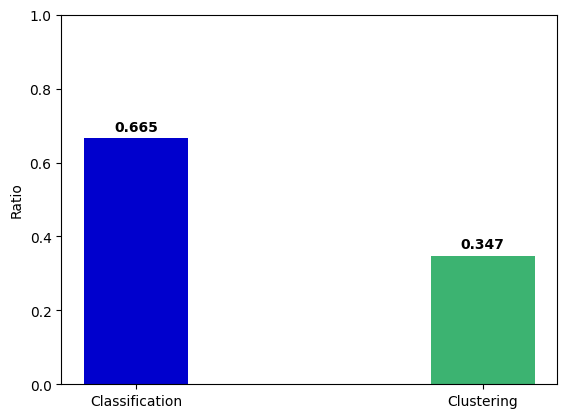

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Vrijednosti
labels = ['Classification', 'Clustering']
values = [0.665, 0.347]

# x pozicije za barove
x = np.arange(len(labels))

# Tanji i bliže barovi
plt.bar(x, values, color=['mediumblue', 'mediumseagreen'], width=0.3)  # manja širina -> tanji
plt.ylim(0, 1)
plt.ylabel('Ratio')

# Dodaj vrijednosti iznad barova
for i, v in enumerate(values):
    plt.text(x[i], v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

# Zamijeni x-ticks sa labelama
plt.xticks(x, labels)

plt.show()
